**Overview**
The purpose of this notebook is to develop a better model for the spikes in a person's levels of glucose and insulin due to external factor such as eating and exercise, this will then be fed into the CGM class simulation to see how well it can adapt. 

 **Research**
 We begin by developing a qualitative understanding of how a diabetic person's insulin and glucose levels behave without regulation. 

 - Blood sugar dips overnight
 - Peaks occur 60-90 minutes after meals and can be more than 50-80 units above baseline
 - dawn phenomemon glucose rise between 3-8 am
 - aerobic exercise can lower glucose
 - anerobic exercise can sometimes increase glucose
 - daily variations can be 30-40%

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import random
def generate_spikes():
    """"Function to generate random artificial spikes based on mealtimes and exercise"""
    # First we create an empty array of the correct length 
    spikes = np.zeros(1440)
    # We model the dawn phenomenon with an average spike of 20 mg/dl
    dp = random.randint(180, 480)
    # Random scaling 
    dpscale = random.uniform(0, 2)
    spikes[dp] = dpscale * 20
    # We model breakfast with a single spike of average 40
    bs = random.randint(420, 540)
    bscale = random.uniform(0, 2)
    spikes[bs] = bscale * 40
    # We next model lunch with a single spike of average 60
    ls = random.randint(660, 780)
    lscale = random.uniform(0, 2)
    spikes[ls] = lscale * 60
    # We model dinner with two spikes 60 and 20 seperated by 20 minutes
    ds = random.randint(1080, 1200)
    dscale = random.uniform(0, 2)
    spikes[ds] = dscale * 60
    spikes[ds + 20] = dscale * 20
    # We add a snack
    ss = random.randint(360, 1380)
    sscale = random.uniform(0, 2)
    spikes[ss] = sscale * 20
    # Now we add exercise
    es = random.randint(360, 1380)
    escale = random.uniform(0, 2)
    spikes[es] = -escale* 35
    return spikes




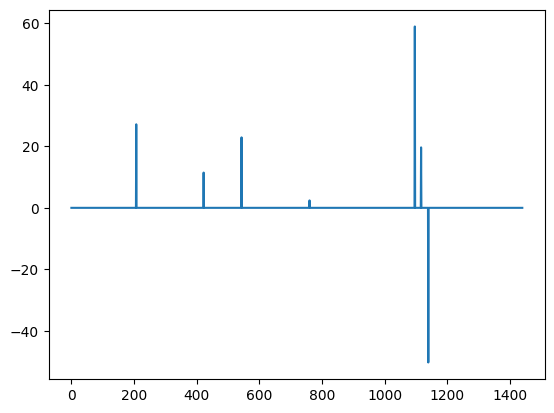

In [11]:
spikes = generate_spikes()
t = np.arange(len(spikes))
plt.plot(t, spikes)

In [21]:
import numpy as np
import scipy.linalg
import scipy.signal
class CGM():
    def __init__(self, a, b, c, d, dt, glucose_penalty, insulin_penalty, controller_penalty, target=83, base_insulin=10):
        # This is our target glucose measurement 
        self.target = target
        # This is the baseline amount of insulin
        self.base_insulin = base_insulin 
        # Our model will penalize the difference between the current state and these baselines

        # Define evolution matrices for AX + Bu
        A = np.array([[-a, -b], [d, -c]])
        B = np.array([[0], [1]])

        # Now we convert to a discrete system since we only sample every few minutes
        # see https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.cont2discrete.html#scipy.signal.cont2discrete
        discrete_system = scipy.signal.cont2discrete((A, B, np.eye(2), np.zeros((2,1))), dt, method='zoh')
        self.A = discrete_system[0]
        self.B = discrete_system[1]
        self.Q = np.array([[glucose_penalty, 0], [0, insulin_penalty]])
        self.R = np.array([controller_penalty])
        self.K = self.fit()
    def fit(self):
        # Solves discrete algebraic riccati equations
        P = scipy.linalg.solve_discrete_are(self.A, self.B, self.Q, self.R)
        return np.linalg.inv(self.R + self.B.T @ P @ self.B) @ (self.B.T @ P @ self.A)
    def control(self, current_values):
        """Given the value observed by the CGM use the objective to apply optimal control"""
        # First we calculate the errors
        glucose, insulin = current_values
        x1 = glucose - self.target
        x2 = insulin - self.base_insulin
        xk = np.array([[x1], [x2]])
        u = -self.K @ xk
        # We can't deliver negative insulin, the indexing is because u is technically a matrix
        u = max(0.0, u[0][0] + self.base_insulin)
        return u 

        

In [22]:
import numpy as np
from scipy.integrate import solve_ivp
def simulate(spikes, t_steps, dt, starting, a, b, c, d, glucose_penalty, insulin_penalty, controller_penalty, target=83, base_insulin=10):
    cgm = CGM(a, b, c, d, dt, glucose_penalty, insulin_penalty, controller_penalty, target, base_insulin)
    def fun(t, x, u):
        xerr = x - np.array([target, base_insulin])
        uerr = u - base_insulin
        dxdt = np.array([[-a, -b], [d, -c]]) @ xerr + np.array([0, 1]) * uerr
        #Make sure we don't get negative insulin
        if x[1] <= 0 and dxdt[1] < 0:
            dxdt[1] = 0
        return dxdt
    current = starting
    t_hist = []
    y_hist = []
    for t in range(0, t_steps, dt):
        current[0] += np.sum(spikes[t:t+dt])
        u = cgm.control(current)
        sol = solve_ivp(fun=fun, t_span=(t, t+dt), y0=current, args=(u,))
        current = np.maximum(0, sol.y[:, -1])
        t_hist.append(sol.t)
        y_hist.append(sol.y)
    return np.concatenate(t_hist), np.concatenate(y_hist, axis=1)


t, states = simulate(spikes, 1440, 5, np.array([130, 40]), 0.01, 0.01, 0.05, 0.0, 10, 0.1, 1000)



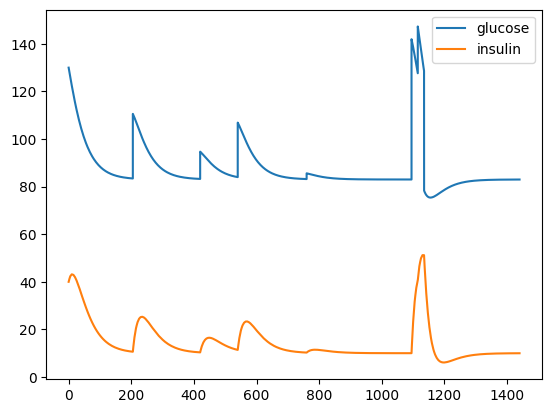

In [23]:
import matplotlib.pyplot as plt
plt.plot(t, states[0], label='glucose')
plt.plot(t, states[1], label='insulin')
plt.legend()